# Concept Linker - Step-by-step Visualization

The linker maps a **free-text finding name** to a **canonical DAG node name**.
Under the hood it is just *one dictionary lookup*.

```
text  -->  strip + lowercase  -->  dictionary lookup  -->  canonical name
                                          |
                                       no match
                                          |
                                          v
                                        None   (never a guess)
```

Examples:
- `"Enlarged Heart"` --> `"Cardiomegaly"`
- `"xyzzy"`          --> `None`


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

from src.linking.linker import ConceptLinker

linker = ConceptLinker("../../data/ontology/synonyms.yaml")
print(f"Linker loaded: {len(linker.lookup)} synonym -> canonical mappings")


Linker loaded: 89 synonym -> canonical mappings


## 1. How the dictionary is built

`synonyms.yaml` lists each finding with its synonyms. The linker **flattens** this
into one big dict where every synonym points to its canonical name.

One entry with N synonyms becomes N dict keys, all pointing to the same name.


In [2]:
import yaml

with open("../../data/ontology/synonyms.yaml", encoding="utf-8") as f:
    entries = yaml.safe_load(f)

# Look at one entry and how it expands into the lookup dict.
card = [e for e in entries if e["canonical"] == "Cardiomegaly"][0]

print("YAML entry for Cardiomegaly:")
print(f"  canonical: {card['canonical']}")
print(f"  synonyms:  {card['synonyms']}")
print()
print("becomes these dict keys (all point to the same name):")
for syn in card["synonyms"]:
    print(f'  "{syn}"  -->  "{card["canonical"]}"')


YAML entry for Cardiomegaly:
  canonical: Cardiomegaly
  synonyms:  ['cardiomegaly', 'enlarged heart', 'heart enlargement', 'cardiac enlargement', 'cardiac hypertrophy', 'heart hypertrophy', 'hypertensive cardiomegaly', 'hypertrophic cardiomegaly']

becomes these dict keys (all point to the same name):
  "cardiomegaly"  -->  "Cardiomegaly"
  "enlarged heart"  -->  "Cardiomegaly"
  "heart enlargement"  -->  "Cardiomegaly"
  "cardiac enlargement"  -->  "Cardiomegaly"
  "cardiac hypertrophy"  -->  "Cardiomegaly"
  "heart hypertrophy"  -->  "Cardiomegaly"
  "hypertensive cardiomegaly"  -->  "Cardiomegaly"
  "hypertrophic cardiomegaly"  -->  "Cardiomegaly"


## 2. Trace one `link()` call

Three steps: strip whitespace, lowercase, then look up in the dict.


In [3]:
def trace_link(text):
    """Show each step of linker.link()."""
    print(f'Input:      "{text}"')

    if not text:
        print("  empty -> None")
        return

    stripped = text.strip()
    lowered = stripped.lower()
    print(f'Stripped:   "{stripped}"')
    print(f'Lowercased: "{lowered}"')

    result = linker.lookup.get(lowered)
    if result:
        print(f'Lookup:     found -> "{result}"')
    else:
        print("Lookup:     not in dict -> None")

    print(f"\nReturns: {linker.link(text)!r}")


trace_link("  Enlarged Heart  ")


Input:      "  Enlarged Heart  "
Stripped:   "Enlarged Heart"
Lowercased: "enlarged heart"
Lookup:     found -> "Cardiomegaly"

Returns: 'Cardiomegaly'


## 3. Try different kinds of input

The same lookup handles canonical names, clinical synonyms, odd casing, and
unknown text. Unknown always returns `None` - never a guess.


In [4]:
examples = [
    "Cardiomegaly",        # canonical name itself
    "enlarged heart",      # clinical synonym
    "GGO",                 # abbreviation
    "PNEUMOTHORAX",        # uppercase
    "  hydrothorax  ",     # extra whitespace
    "broken rib",          # not a VinDr finding
]

print(f'{"input":24s} -> result')
print("-" * 46)
for text in examples:
    print(f"{text!r:24s} -> {linker.link(text)!r}")


input                    -> result
----------------------------------------------
'Cardiomegaly'           -> 'Cardiomegaly'
'enlarged heart'         -> 'Cardiomegaly'
'GGO'                    -> 'Lung Opacity'
'PNEUMOTHORAX'           -> 'Pneumothorax'
'  hydrothorax  '        -> 'Pleural effusion'
'broken rib'             -> None


## 4. How many synonyms does each finding have?

More synonyms means more free-text variants the linker can catch.


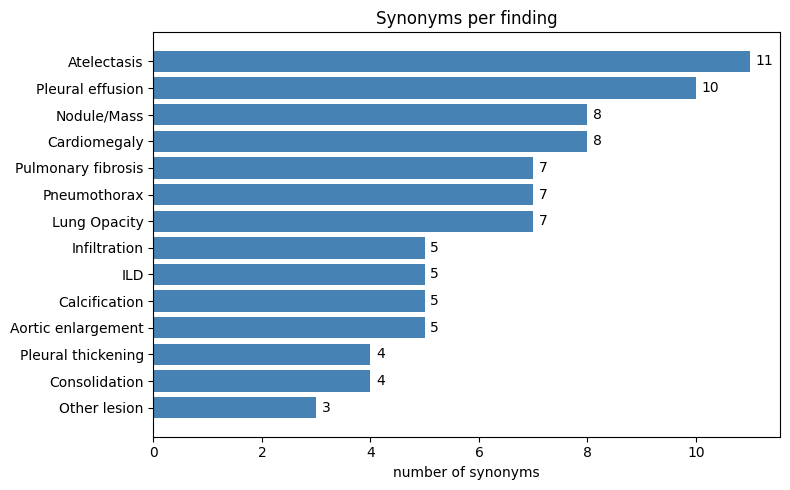

Total: 89 synonyms across 14 findings


In [5]:
import matplotlib.pyplot as plt

names = [e["canonical"] for e in entries]
counts = [len(e["synonyms"]) for e in entries]

# sort smallest-to-largest so the bar chart reads top-down
order = sorted(range(len(names)), key=lambda i: counts[i])
names = [names[i] for i in order]
counts = [counts[i] for i in order]

plt.figure(figsize=(8, 5))
plt.barh(names, counts, color="steelblue")
plt.xlabel("number of synonyms")
plt.title("Synonyms per finding")
for i, c in enumerate(counts):
    plt.text(c + 0.1, i, str(c), va="center")
plt.tight_layout()
plt.show()

print(f"Total: {sum(counts)} synonyms across {len(names)} findings")


## 5. Gold check: does it resolve every VinDr finding?

Run the linker on the `gt_finding` of all VinDr questions. Every one should
resolve - this is the `linking_accuracy` metric from the spec.


In [6]:
import json

with open("../../data/vindr_cxr_vqa/vqa.json") as f:
    data = json.load(f)

gold = [item["gt_finding"] for img in data for item in img["vqa"]]
resolved = sum(1 for f in gold if linker.link(f) is not None)

print(f"linking_accuracy = {resolved / len(gold) * 100:.2f}%  ({resolved}/{len(gold)})")


linking_accuracy = 100.00%  (17597/17597)
